In [8]:
# Prepare Data
import os
import sys
import yaml
import torch
import pickle
import warnings
import setproctitle
import numpy as np
import sympy as sp
import pandas as pd
import torch.utils.data as D
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import display
from copy import deepcopy
from scipy.optimize import minimize
from ND2.model import NDformer
from ND2.utils import init_logger
from ND2.search import MCTS
from ND2.GDExpr import GDExpr
from ND2.dataset import Dataset
from ND2.utils import AttrDict, get_fig, seed_all
from ND2.search.reward_solver import RewardSolver, RolloutRewardSolver

warnings.filterwarnings("ignore", category=RuntimeWarning)
seed_all(42)


data_path = './data/bacteria/'
data_list = [
    *list(np.array(eval(open(f'{data_path}/low/numes_6.json').read()))[(2,), 0, :, :]),
    # *list(np.array(eval(open(f'{data_path}/low/numes_6.json').read()))[(2,3), 0, :, :])
] # List of np.ndarray(T+1, V), T=10, V=[3,6,12,24]

data = np.concatenate(data_list, axis=-1) # (T, V_sum)
x = data[:-1, :] # (T, V_sum)
y = np.diff(data, axis=0) # (T, V_sum)
T, V = x.shape
A = np.zeros((V, V), dtype=int)
tmp = np.cumsum([0, *[d.shape[-1] for d in data_list]])
for i, j in zip(tmp[:-1], tmp[1:]): A[i:j, i:j] = 1 - np.eye(j-i)
G = np.stack(np.nonzero(A), axis=-1) # (E, 2)
E = G.shape[0]
data = dict(A=A, G=G, dx=y, x=x)
assert E == sum(d.shape[-1] * (d.shape[-1] - 1) for d in data_list)


In [59]:
data['x'].shape

(10, 6)

In [9]:
reward_solver = RewardSolver(
    Xv={'x': data['x']},
    Xe={},
    A=data['A'],
    G=data['G'],
    Y=data['dx']
)

rollout_solver = RolloutRewardSolver(
    Xv={'x': data['x']},
    Xe={},
    A=data['A'],
    G=data['G'],
    Y=data['dx']
)

def evaluate(expr, N=10, x0=None, max_iter=100):
    prefix = GDExpr.sympy2prefix(GDExpr.parse_expr(expr), 'node', reindex=False, keep_coeff=True)
    prefix_with_coef = reward_solver.solve(prefix, x0=x0, max_iter=max_iter)[1]
    single_step = reward_solver.evaluate(prefix_with_coef)

    true = np.concatenate([data['x'], data['x'][(-1,), :] + data['dx'][(-1,), :]], axis=0)
    pred = [data['x'][[0]]]
    for t in range(T):
        for n in range(N):
            y = GDExpr.eval(prefix_with_coef, {**data, 'x': pred[-1]}, [], strict=False)
            x_ = pred[-1] + y / N
            x_ = x_.clip(0, 1)
            pred.append(x_)
    pred_all = np.concatenate(pred, axis=0)
    pred = pred_all[::N]
    R2 = 1 - np.sum((pred - true) ** 2) / np.sum((true - np.mean(true)) ** 2)
    RMSE = np.sqrt(np.mean((pred - true) ** 2))
    sMAPE = 2 * np.mean(np.abs(pred - true) / (np.abs(pred) + np.abs(true)).clip(1e-6))
    rollout = {
        'R2': R2,
        'RMSE': RMSE,
        'sMAPE': sMAPE,
        'time': np.arange(T+1),
        'time_all': np.arange(N*T+1)/N,
        'true': true,
        'pred_all': pred_all
    }
    return prefix_with_coef, single_step, rollout

def repeat(*args, repeat=10, stop=0.02, log=True, **kwargs):
    expr = args[0]
    best = None
    for _ in range(repeat):
        result = evaluate(expr, N=kwargs.get('N', 10), x0=kwargs.get('x0', None)) # prefix_with_coef, single_step, rollout
        if best is None or result[2]['RMSE'] < best[2]['RMSE']:
            best = result
        if log: print(result[2]['RMSE'])
        if result[2]['RMSE'] < stop: break
    return best

In [58]:
data['A'].shape[0], data['G'].shape[0]

(6, 30)

0.02106156256692256
0.021331707265887248
0.021025846659547258
0.02133137321670491
0.021642284459788885
0.020707844069669645
0.02169710166617093
0.02202223168024187
0.02110658657860253
0.02095704699450036
Single-step reward: R2=0.8166, RMSE=0.0151, sMAPE=80.32%
Rollout reward: R2=0.9253, RMSE=0.0207, sMAPE=29.63%


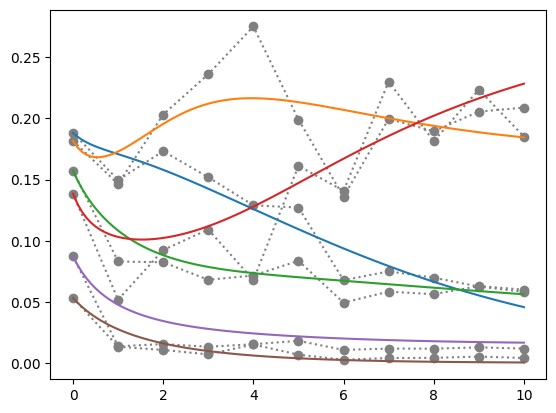

In [10]:
# Lotka-Volterra
expr = 'x * (<Cv> - <Cv> * x) + aggr(<Ce> * sour(x) * targ(x))'
prefix_with_coef, single_step, rollout = repeat(expr, repeat=10)

print(f'Single-step reward: R2={single_step["R2"]:.4f}, RMSE={single_step["RMSE"]:.4f}, sMAPE={single_step["sMAPE"]:.2%}')
print(f'Rollout reward: R2={rollout["R2"]:.4f}, RMSE={rollout["RMSE"]:.4f}, sMAPE={rollout["sMAPE"]:.2%}')

plt.plot(rollout['time'], rollout['true'], 'o:', label='True', color='gray')
for i in range(V):
    plt.plot(rollout['time_all'], rollout['pred_all'][:, i], label='Pred', color=f'C{i}')

0.029290741213162757
0.02223847206479167
0.023428584522389162
0.024144921696156837
0.024474733953559463
0.031113356288304153
0.02365191946927794
0.054390672464169704
0.023603560176658957
0.024335738913182386
Single-step reward: R2=0.8078, RMSE=0.0155, sMAPE=88.94%
Rollout reward: R2=0.9139, RMSE=0.0222, sMAPE=29.96%


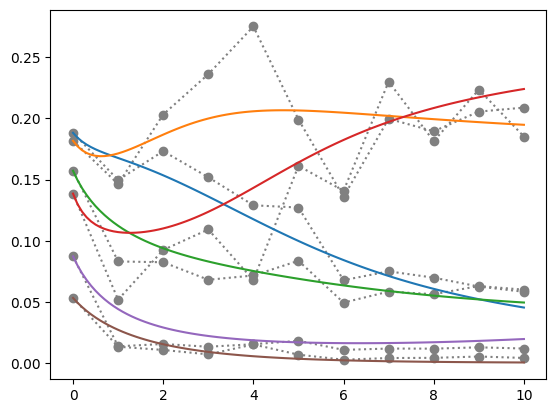

In [ ]:
# Holling Type II
expr = 'x * (<Cv> - <Cv> * x) + aggr(<Ce> * sour(x)/(1+<Ce>*sour(x)) * targ(x))'
prefix_with_coef, single_step, rollout = repeat(expr, repeat=10)

print(f'Single-step reward: R2={single_step["R2"]:.4f}, RMSE={single_step["RMSE"]:.4f}, sMAPE={single_step["sMAPE"]:.2%}')
print(f'Rollout reward: R2={rollout["R2"]:.4f}, RMSE={rollout["RMSE"]:.4f}, sMAPE={rollout["sMAPE"]:.2%}')

plt.plot(rollout['time'], rollout['true'], 'o:', label='True', color='gray')
for i in range(V):
    plt.plot(rollout['time_all'], rollout['pred_all'][:, i], label='Pred', color=f'C{i}')

0.022073006447968845
0.022713020786126668
0.022351359128468504
0.022186231237210644
0.022616451080627663
0.02279630160785196
0.022024655723323093
0.02334648629195866
0.022609793331779114
0.022453632971010815
Single-step reward: R2=0.7420, RMSE=0.0180, sMAPE=90.29%
Rollout reward: R2=0.9155, RMSE=0.0220, sMAPE=36.40%


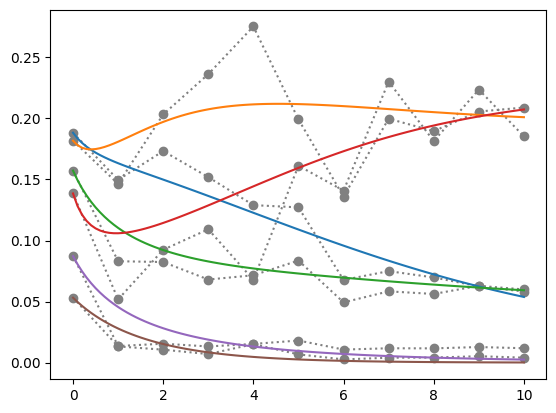

In [63]:
# Holling Type III
expr = 'x * (<Cv> - <Cv> * x) + aggr(<Ce> * sour(x**2)/(1+<Ce>*sour(x**2)) * targ(x))'
prefix_with_coef, single_step, rollout = repeat(expr, repeat=10)

print(f'Single-step reward: R2={single_step["R2"]:.4f}, RMSE={single_step["RMSE"]:.4f}, sMAPE={single_step["sMAPE"]:.2%}')
print(f'Rollout reward: R2={rollout["R2"]:.4f}, RMSE={rollout["RMSE"]:.4f}, sMAPE={rollout["sMAPE"]:.2%}')

plt.plot(rollout['time'], rollout['true'], 'o:', label='True', color='gray')
for i in range(V):
    plt.plot(rollout['time_all'], rollout['pred_all'][:, i], label='Pred', color=f'C{i}')

0.4335117724845027
0.08930937886964466
0.20065958429422528
0.37486830407336
0.20636846483757304
0.42793853719138364
0.24607990803106172
0.5793050791662325
0.5965413024990068
0.6469042478024359
Single-step reward: R2=0.2781, RMSE=0.0301, sMAPE=124.82%
Rollout reward: R2=-0.3891, RMSE=0.0893, sMAPE=83.95%


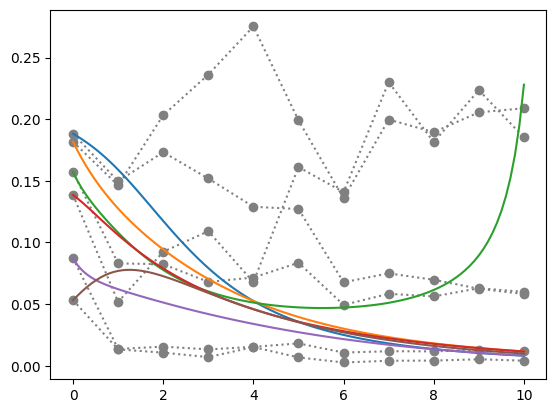

In [69]:
# Leslie-Gower
expr = 'x * (<Cv> - <Cv> * x) + aggr(<Ce> * targ(x**2) / (<Ce>+sour(x)))'
prefix_with_coef, single_step, rollout = repeat(expr, repeat=10)

print(f'Single-step reward: R2={single_step["R2"]:.4f}, RMSE={single_step["RMSE"]:.4f}, sMAPE={single_step["sMAPE"]:.2%}')
print(f'Rollout reward: R2={rollout["R2"]:.4f}, RMSE={rollout["RMSE"]:.4f}, sMAPE={rollout["sMAPE"]:.2%}')

plt.plot(rollout['time'], rollout['true'], 'o:', label='True', color='gray')
for i in range(V):
    plt.plot(rollout['time_all'], rollout['pred_all'][:, i], label='Pred', color=f'C{i}')

Single-step reward: R2=-16.2643, RMSE=0.1470, sMAPE=132.71%
Rollout reward: R2=0.9797, RMSE=0.0108, sMAPE=17.45%


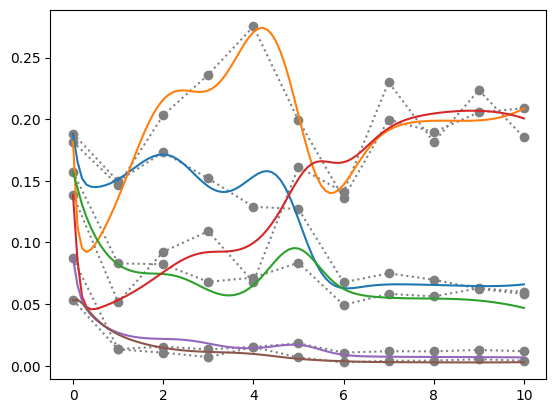

In [27]:
# Ours
expr = 'x * (<Cv> - <Cv> * x) + aggr(<Ce> * regular(sour(x), targ(x)))'
prefix_with_coef, single_step, rollout = evaluate(expr, N=10, max_iter=0, x0={'<C>': np.empty(0), '<Cv>': np.array([[-2.53119763578802,-8.399051979347995,-0.6587625878018357,-8.263587704737887,-4.6453194269693885,0.7944164901808562],[-2.758174073703573,1.3497755553765536,-2.706413796421654,2.6028543446224846,0.9415191899553748,-0.14117980568968627]]), '<Ce>': np.array([[18.014322494813253,-1.8873131669571468,-5.43635763366833,8.6934907473064,-2.172182523070545,4.224301312917578,6.344743844136895,8.890210197341446,-0.6777505719205829,2.330443678330202,2.2350325822766854,-4.575068186740982,4.182275236443787,3.9793763093900694,-6.345715150874687,-4.025971409818495,1.1424257866581795,-0.2850870845841411,-6.690035361493452,1.4787039752552054,-5.884850411995562,-14.760639255101252,-9.788015055713712,4.8730615934658426,4.711107966402763,3.7545281052629247,1.1785610846608847,5.3348085294729595,-11.781333224203703,-5.2654729791922215]])})

print(f'Single-step reward: R2={single_step["R2"]:.4f}, RMSE={single_step["RMSE"]:.4f}, sMAPE={single_step["sMAPE"]:.2%}')
print(f'Rollout reward: R2={rollout["R2"]:.4f}, RMSE={rollout["RMSE"]:.4f}, sMAPE={rollout["sMAPE"]:.2%}')

plt.plot(rollout['time'], rollout['true'], 'o:', label='True', color='gray')
for i in range(V):
    plt.plot(rollout['time_all'], rollout['pred_all'][:, i], label='Pred', color=f'C{i}')

In [1]:
import pandas as pd

df = pd.read_json('./result/neural_baseline_ecological.csv', lines=True)
df['N'] = df['hidden_dim'].apply(lambda x: len(x))
df['D'] = df['hidden_dim'].apply(lambda x: x[0])
df['hidden_dim'] = df['hidden_dim'].apply(lambda x: str(x))
df

,host,lr,batch_size,dropout,hidden_dim,seed,model,name,RMSE,loss,...,sMAPE,epoch,final_loss,final_ssRMSE,final_sssMAPE,final_RMSE,final_sMAPE,time,N,D
0,rl3,0.0010,4,0.5,"[64, 64]",18462,GNN,NeuralBaseline_20250527_141906,0.033283,0.003956,...,0.226947,35,0.002618,0.033591,0.775208,0.047673,0.308132,NaN,2,64
1,rl3,0.0001,2,0.3,"[32, 32, 32, 32]",14136,GNN,NeuralBaseline_20250527_142429,0.033065,0.002778,...,0.250589,85,0.001582,0.032513,0.701412,0.034214,0.227558,NaN,4,32
2,rl3,0.0001,2,0.3,"[64, 64]",17106,GNN,NeuralBaseline_20250527_142430,0.028599,0.001404,...,0.120842,348,0.001117,0.025691,0.559379,0.028774,0.136785,NaN,2,64
3,rl3,0.0001,2,0.3,"[32, 32]",31362,GNN,NeuralBaseline_20250527_142428,0.029415,0.002353,...,0.195525,434,0.002133,0.028010,0.566066,0.029629,0.133582,NaN,2,32
4,rl3,0.0001,2,0.5,"[32, 32]",16960,GNN,NeuralBaseline_20250527_142429,0.040105,0.005003,...,0.275878,541,0.004413,0.034268,0.769438,0.041134,0.286073,NaN,2,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320,rl3,0.0100,8,0.0,"[64, 64, 64, 64]",20237,GNN,NeuralBaseline_20250527_191036,0.028318,0.000447,...,0.118642,1675,0.000779,0.024470,0.572213,0.028393,0.124342,449.267271,4,64
321,rl3,0.0100,8,0.0,"[32, 32, 32, 32]",21735,GNN,NeuralBaseline_20250527_190957,0.027844,0.000462,...,0.116152,1898,0.000549,0.024167,0.563907,0.028054,0.128124,494.532772,4,32
322,rl3,0.0100,8,0.0,"[64, 64]",30494,GNN,NeuralBaseline_20250527_190535,0.029526,0.000870,...,0.165557,3399,0.000713,0.028328,0.601612,0.029536,0.164824,757.391211,2,64
323,rl3,0.0100,8,0.0,"[128, 128, 128]",8746,GNN,NeuralBaseline_20250527_190946,0.029913,0.000635,...,0.151228,4927,0.000833,0.028985,0.600955,0.029915,0.153175,753.334617,3,128


In [2]:
df.loc[df.groupby('hidden_dim')['RMSE'].idxmin()]

,host,lr,batch_size,dropout,hidden_dim,seed,model,name,RMSE,loss,...,sMAPE,epoch,final_loss,final_ssRMSE,final_sssMAPE,final_RMSE,final_sMAPE,time,N,D
297,rl3,0.0010,8,0.0,"[128, 128, 128, 128]",30337,GNN,NeuralBaseline_20250527_184525,0.027772,0.000544,...,0.113998,1441,0.000442,0.024400,0.562111,0.027939,0.117344,715.609186,4,128
286,rl3,0.0010,4,0.0,"[128, 128, 128]",31133,GNN,NeuralBaseline_20250527_183431,0.027766,0.000616,...,0.119375,979,0.000584,0.024260,0.561726,0.027902,0.123614,591.181417,3,128
61,rl3,0.0001,8,0.5,"[128, 128]",24640,GNN,NeuralBaseline_20250527_150115,0.027657,0.006909,...,0.280589,96,0.001601,0.025509,0.580654,0.028664,0.176664,233.420386,2,128
294,rl3,0.0010,8,0.0,"[32, 32, 32, 32]",20218,GNN,NeuralBaseline_20250527_184359,0.027682,0.000731,...,0.123192,1137,0.000766,0.024017,0.565147,0.027858,0.120332,630.455551,4,32
316,rl3,0.0100,8,0.0,"[32, 32, 32]",16701,GNN,NeuralBaseline_20250527_190834,0.027779,0.000615,...,0.114378,1203,0.000570,0.024192,0.565319,0.027801,0.113164,379.630322,3,32
278,rl3,0.0010,4,0.0,"[32, 32]",196,GNN,NeuralBaseline_20250527_183328,0.027883,0.000913,...,0.124925,99,0.000543,0.024409,0.552729,0.028445,0.137729,238.121311,2,32
293,rl3,0.0010,8,0.0,"[64, 64, 64, 64]",32419,GNN,NeuralBaseline_20250527_184429,0.027766,0.000562,...,0.131260,976,0.000456,0.024455,0.543289,0.028205,0.139215,571.269741,4,64
295,rl3,0.0010,8,0.0,"[64, 64, 64]",10103,GNN,NeuralBaseline_20250527_184330,0.027962,0.000536,...,0.142555,1339,0.000605,0.024302,0.567172,0.028195,0.131342,699.077148,3,64
264,rl3,0.0001,8,0.0,"[64, 64]",27355,GNN,NeuralBaseline_20250527_181708,0.027825,0.000566,...,0.140059,1103,0.000434,0.024385,0.571284,0.028066,0.127348,627.702305,2,64


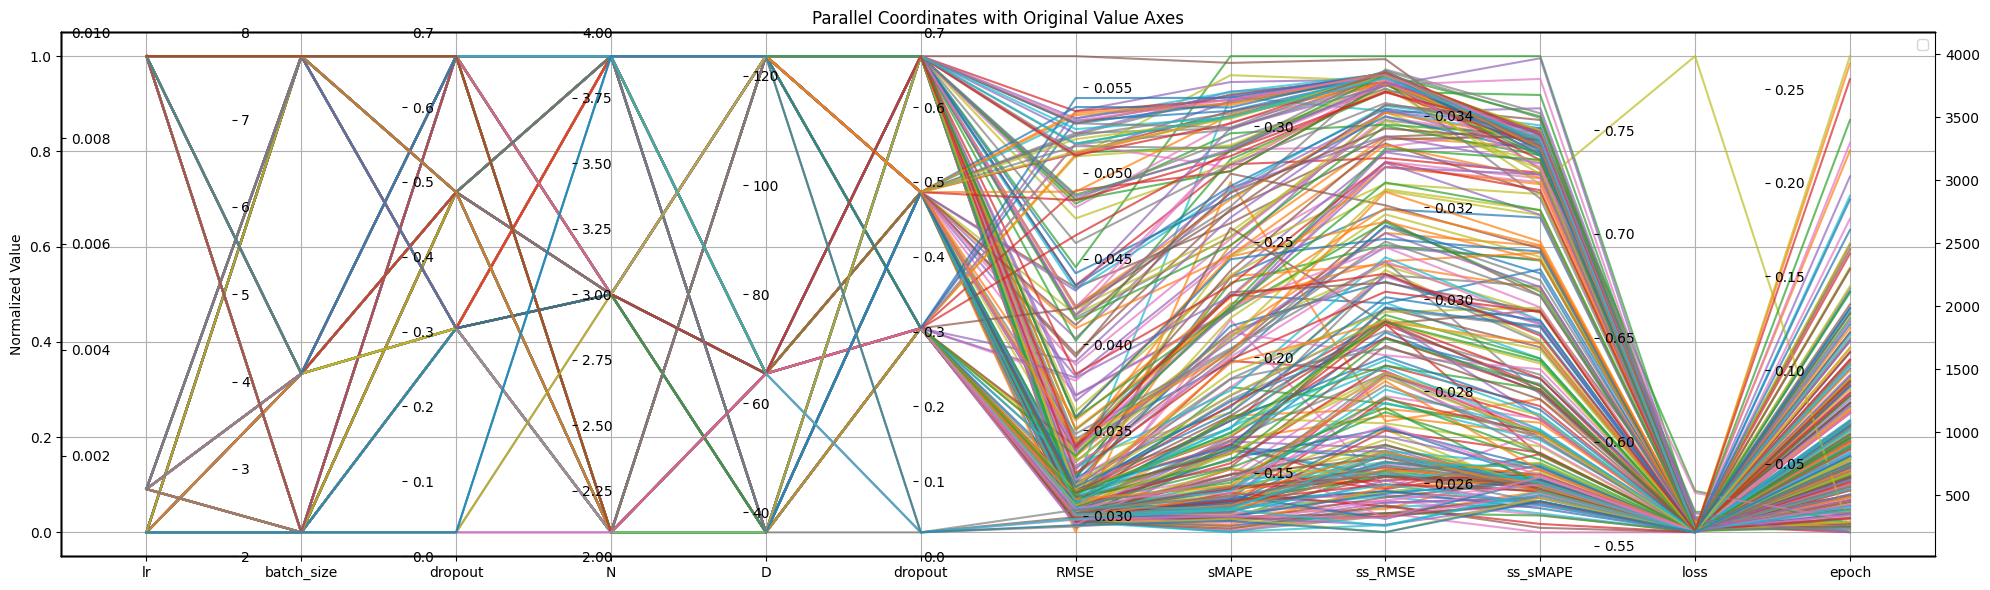

In [20]:
from sklearn.preprocessing import MinMaxScaler

features = ['lr', 'batch_size', 'dropout', 'N', 'D', 'dropout', 'RMSE', 'sMAPE', 'ss_RMSE', 'ss_sMAPE', 'loss', 'epoch']

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

# 创建主图
fig, ax = plt.subplots(figsize=(20, 6))

# 每个样本画线
for i in range(len(df_scaled)):
    row = df_scaled.iloc[i]
    values = row[features].values
    ax.plot(range(len(features)), values, alpha=0.7)

# 设置主x轴
ax.set_xticks(range(len(features)))
ax.set_xticklabels(features)
ax.set_ylabel("Normalized Value")
ax.set_title("Parallel Coordinates with Original Value Axes")
ax.grid(True)

# 为每个特征添加一个独立的 y 轴显示原始值
for i, feature in enumerate(features):
    # 新建坐标轴
    ax_twin = ax.twinx()
    ax_twin.set_ylim(scaler.data_min_[i], scaler.data_max_[i])
    
    # 设置坐标轴位置
    ax_twin.spines["right"].set_position(("axes", i / (len(features) - 1)))
    
    # 只保留刻度，不画轴线
    ax_twin.spines["right"].set_visible(False)
    ax_twin.yaxis.set_ticks_position('right')
    # ax_twin.set_ylabel(feature + " (original)", rotation=0, labelpad=40, va='center')

# 避免重复图例
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()